# GreenMetal AI: Advanced Model Training Pipeline
## Building BEST Models with Maximum Accuracy

**Objective:** Train multiple high-performance ML models and select the best one

**Models to Train:**
1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. LightGBM Classifier
5. Support Vector Machine (SVM)
6. Neural Network (Deep Learning)
7. Voting Ensemble (Best of All)

**Output:** Best model with >90% accuracy target

---


## Step 1: Import Libraries & Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')

# ML Libraries
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_auc_score, roc_curve)

# XGBoost & LightGBM
try:
    import xgboost as xgb
    print('✓ XGBoost available')
except:
    print('Installing XGBoost...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb
    print('✓ XGBoost installed')

try:
    import lightgbm as lgb
    print('✓ LightGBM available')
except:
    print('Installing LightGBM...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb
    print('✓ LightGBM installed')

# Deep Learning
try:
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam
    print('✓ TensorFlow available')
except:
    print('Installing TensorFlow...')
    import subprocess
    subprocess.check_call(['pip', 'install', 'tensorflow', '-q'])
    from tensorflow.keras import Sequential
    from tensorflow.keras.layers import Dense, Dropout
    from tensorflow.keras.optimizers import Adam
    print('✓ TensorFlow installed')

# Configuration
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('\n✓ All libraries imported successfully!')

✓ XGBoost available
✓ LightGBM available
✓ TensorFlow available

✓ All libraries imported successfully!


## Step 2: Load Your Cleaned Datasets


In [3]:
print('='*80)
print('LOADING YOUR CLEANED DATASETS')
print('='*80)

# Load datasets
final_df = pd.read_csv('Green-Metal-Final-Dataset.csv')
plants_df = pd.read_csv('Cleaned-Hyperaccumulator-Plants-Data.csv')

print(f'\n1. Final Dataset: {final_df.shape}')
print(f'   Columns: {final_df.shape[1]}')
print(f'   Missing values: {final_df.isnull().sum().sum()}')

print(f'\n2. Plants Dataset: {plants_df.shape}')
print(f'   Species: {len(plants_df)}')

# Display key info
print(f'\n3. Available metals: {plants_df["Target_Metal"].unique()}')
print(f'\n4. Feature columns (sample):')
print(final_df.columns.tolist())

LOADING YOUR CLEANED DATASETS

1. Final Dataset: (84, 41)
   Columns: 41
   Missing values: 62

2. Plants Dataset: (20, 11)
   Species: 20

3. Available metals: ['Ni' 'Zn' 'As' 'Pb' 'Cu' 'Cd' 'Se']

4. Feature columns (sample):
['Sample_ID', 'Latitude', 'Longitude', 'Soil_Depth_cm', 'pH', 'Ni_ppm', 'Co_ppm', 'Zn_ppm', 'Cu_ppm', 'Pb_ppm', 'Cd_ppm', 'Mn_ppm', 'Fe_ppm', 'Soil_OM_percent', 'Soil_Moisture_percent', 'Sand_percent', 'Silt_percent', 'Clay_percent', 'CEC_meq_per_100g', 'Annual_Rainfall_mm', 'Average_Temp_C', 'Growing_Season_days', 'Elevation_m', 'Solar_Radiation_MJ_m2', 'Wind_Speed_m_s', 'Soil_Drainage', 'Industrial_Proximity_km', 'Mining_Activity_History', 'Contamination_Source', 'Pollutant_Concentration_Index', 'Avg_Metal_ppm', 'Total_Metal_ppm', 'Max_Metal_ppm', 'Soil_Texture_Type', 'Drainage_Score', 'Mining_Activity_Score', 'Contamination_Source_Score', 'Rainfall_Normalized', 'Temp_Normalized', 'Environmental_Score', 'Contamination_Viability']


## Step 3: Prepare Data for Model Training


In [4]:
print('\n' + '='*80)
print('PREPARING DATA FOR MODEL TRAINING')
print('='*80)

# Create a working copy
df = final_df.copy()

# Create target variable: Dominant Metal (highest concentration)
metal_cols = ['Ni_ppm', 'Co_ppm', 'Zn_ppm', 'Cu_ppm', 'Pb_ppm', 'Cd_ppm', 'Mn_ppm', 'Fe_ppm']
df['Dominant_Metal'] = df[metal_cols].idxmax(axis=1).str.replace('_ppm', '')

print(f'\n1. Target Variable Created: Dominant_Metal')
print(f'   Distribution:')
print(df['Dominant_Metal'].value_counts())

# Select features for modeling
feature_cols = [
    # Soil properties
    'pH', 'Soil_OM_percent', 'Soil_Moisture_percent',
    'Sand_percent', 'Silt_percent', 'Clay_percent', 'CEC_meq_per_100g',
    # Metal concentrations
    'Ni_ppm', 'Co_ppm', 'Zn_ppm', 'Cu_ppm', 'Pb_ppm', 'Cd_ppm', 'Mn_ppm', 'Fe_ppm',
    # Environmental
    'Annual_Rainfall_mm', 'Average_Temp_C', 'Growing_Season_days', 'Elevation_m',
    'Solar_Radiation_MJ_m2', 'Wind_Speed_m_s',
    # Soil Drainage (encode)
    'Drainage_Score',
    # Risk factors
    'Industrial_Proximity_km', 'Mining_Activity_Score',
    'Contamination_Source_Score', 'Pollutant_Concentration_Index',
    # Engineered features
    'Avg_Metal_ppm', 'Total_Metal_ppm', 'Max_Metal_ppm',
    'Environmental_Score', 'Contamination_Viability'
]

# Prepare X and y
X = df[feature_cols].copy()
y = df['Dominant_Metal'].copy()

print(f'\n2. Feature Set Prepared')
print(f'   Number of features: {len(feature_cols)}')
print(f'   Number of samples: {len(X)}')
print(f'   Missing values in X: {X.isnull().sum().sum()}')

# Handle any missing values
X = X.fillna(X.mean())

# Encode target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f'\n3. Target Variable Encoded')
print(f'   Classes: {le.classes_}')
print(f'   Number of classes: {len(le.classes_)}')

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f'\n4. Train-Test Split (80-20, Stratified)')
print(f'   Training set: {X_train.shape[0]} samples')
print(f'   Test set: {X_test.shape[0]} samples')

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\n5. Feature Scaling Applied')
print(f'   Scaler fitted on training set')
print(f'\n✓ Data preparation complete!')


PREPARING DATA FOR MODEL TRAINING

1. Target Variable Created: Dominant_Metal
   Distribution:
Dominant_Metal
Fe    71
Mn    11
Zn     2
Name: count, dtype: int64

2. Feature Set Prepared
   Number of features: 31
   Number of samples: 84
   Missing values in X: 31

3. Target Variable Encoded
   Classes: ['Fe' 'Mn' 'Zn']
   Number of classes: 3

4. Train-Test Split (80-20, Stratified)
   Training set: 67 samples
   Test set: 17 samples

5. Feature Scaling Applied
   Scaler fitted on training set

✓ Data preparation complete!


## Step 4: Train Model 1 - Random Forest (Baseline)


In [5]:
print('\n' + '='*80)
print('MODEL 1: RANDOM FOREST CLASSIFIER')
print('='*80)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=3,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

print('\nTraining...')
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_proba_rf = rf_model.predict_proba(X_test_scaled)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {rf_acc:.4f} ({rf_acc*100:.2f}%)')
print(f'  Precision: {rf_precision:.4f}')
print(f'  Recall: {rf_recall:.4f}')
print(f'  F1-Score: {rf_f1:.4f}')

# Cross-validation
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\nCross-Validation (5-fold):')
print(f'  Mean Accuracy: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})')


MODEL 1: RANDOM FOREST CLASSIFIER

Training...

Performance Metrics:
  Accuracy: 0.8235 (82.35%)
  Precision: 0.6782
  Recall: 0.8235
  F1-Score: 0.7438

Cross-Validation (5-fold):
  Mean Accuracy: 0.8505 (+/- 0.0054)


## Step 5: Train Model 2 - Gradient Boosting


In [6]:
print('\n' + '='*80)
print('MODEL 2: GRADIENT BOOSTING CLASSIFIER')
print('='*80)

gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

print('\nTraining...')
gb_model.fit(X_train_scaled, y_train)

y_pred_gb = gb_model.predict(X_test_scaled)
y_proba_gb = gb_model.predict_proba(X_test_scaled)

gb_acc = accuracy_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted')
gb_precision = precision_score(y_test, y_pred_gb, average='weighted')
gb_recall = recall_score(y_test, y_pred_gb, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)')
print(f'  Precision: {gb_precision:.4f}')
print(f'  Recall: {gb_recall:.4f}')
print(f'  F1-Score: {gb_f1:.4f}')

cv_scores_gb = cross_val_score(gb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\nCross-Validation (5-fold):')
print(f'  Mean Accuracy: {cv_scores_gb.mean():.4f} (+/- {cv_scores_gb.std():.4f})')


MODEL 2: GRADIENT BOOSTING CLASSIFIER

Training...

Performance Metrics:
  Accuracy: 0.7647 (76.47%)
  Precision: 0.7896
  Recall: 0.7647
  F1-Score: 0.7712

Cross-Validation (5-fold):
  Mean Accuracy: 0.8945 (+/- 0.0627)


## Step 6: Train Model 3 - XGBoost


In [7]:
print('\n' + '='*80)
print('MODEL 3: XGBOOST CLASSIFIER')
print('='*80)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print('\nTraining...')
xgb_model.fit(X_train_scaled, y_train, verbose=0)

y_pred_xgb = xgb_model.predict(X_test_scaled)
y_proba_xgb = xgb_model.predict_proba(X_test_scaled)

xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb, average='weighted')
xgb_precision = precision_score(y_test, y_pred_xgb, average='weighted')
xgb_recall = recall_score(y_test, y_pred_xgb, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {xgb_acc:.4f} ({xgb_acc*100:.2f}%)')
print(f'  Precision: {xgb_precision:.4f}')
print(f'  Recall: {xgb_recall:.4f}')
print(f'  F1-Score: {xgb_f1:.4f}')

cv_scores_xgb = cross_val_score(xgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\nCross-Validation (5-fold):')
print(f'  Mean Accuracy: {cv_scores_xgb.mean():.4f} (+/- {cv_scores_xgb.std():.4f})')


MODEL 3: XGBOOST CLASSIFIER

Training...

Performance Metrics:
  Accuracy: 0.8235 (82.35%)
  Precision: 0.7206
  Recall: 0.8235
  F1-Score: 0.7686

Cross-Validation (5-fold):
  Mean Accuracy: nan (+/- nan)


## Step 7: Train Model 4 - LightGBM


In [9]:
print('\n' + '='*80)
print('MODEL 4: LIGHTGBM CLASSIFIER')
print('='*80)

lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=7,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    class_weight='balanced'
)

print('\nTraining...')
lgb_model.fit(X_train_scaled, y_train)

y_pred_lgb = lgb_model.predict(X_test_scaled)
y_proba_lgb = lgb_model.predict_proba(X_test_scaled)

lgb_acc = accuracy_score(y_test, y_pred_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb, average='weighted')
lgb_precision = precision_score(y_test, y_pred_lgb, average='weighted')
lgb_recall = recall_score(y_test, y_pred_lgb, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {lgb_acc:.4f} ({lgb_acc*100:.2f}%)')
print(f'  Precision: {lgb_precision:.4f}')
print(f'  Recall: {lgb_recall:.4f}')
print(f'  F1-Score: {lgb_f1:.4f}')

cv_scores_lgb = cross_val_score(lgb_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\nCross-Validation (5-fold):')
print(f'  Mean Accuracy: {cv_scores_lgb.mean():.4f} (+/- {cv_scores_lgb.std():.4f})')


MODEL 4: LIGHTGBM CLASSIFIER

Training...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000193 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 67, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## Step 8: Train Model 5 - Support Vector Machine


In [10]:
print('\n' + '='*80)
print('MODEL 5: SUPPORT VECTOR MACHINE (SVM)')
print('='*80)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42,
    class_weight='balanced'
)

print('\nTraining...')
svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)
y_proba_svm = svm_model.predict_proba(X_test_scaled)

svm_acc = accuracy_score(y_test, y_pred_svm)
svm_f1 = f1_score(y_test, y_pred_svm, average='weighted')
svm_precision = precision_score(y_test, y_pred_svm, average='weighted')
svm_recall = recall_score(y_test, y_pred_svm, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)')
print(f'  Precision: {svm_precision:.4f}')
print(f'  Recall: {svm_recall:.4f}')
print(f'  F1-Score: {svm_f1:.4f}')

cv_scores_svm = cross_val_score(svm_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'\nCross-Validation (5-fold):')
print(f'  Mean Accuracy: {cv_scores_svm.mean():.4f} (+/- {cv_scores_svm.std():.4f})')


MODEL 5: SUPPORT VECTOR MACHINE (SVM)

Training...

Performance Metrics:
  Accuracy: 0.8824 (88.24%)
  Precision: 0.8382
  Recall: 0.8824
  F1-Score: 0.8471

Cross-Validation (5-fold):
  Mean Accuracy: 0.8505 (+/- 0.0054)


## Step 9: Train Model 6 - Neural Network (Deep Learning)


In [11]:
print('\n' + '='*80)
print('MODEL 6: DEEP NEURAL NETWORK')
print('='*80)

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import Sequential
from tensorflow.keras.optimizers import Adam

# Build neural network
nn_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(len(le.classes_), activation='softmax')
])

nn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print('\nTraining...')
history = nn_model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

y_pred_nn = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)
y_proba_nn = nn_model.predict(X_test_scaled, verbose=0)

nn_acc = accuracy_score(y_test, y_pred_nn)
nn_f1 = f1_score(y_test, y_pred_nn, average='weighted')
nn_precision = precision_score(y_test, y_pred_nn, average='weighted')
nn_recall = recall_score(y_test, y_pred_nn, average='weighted')

print(f'\nPerformance Metrics:')
print(f'  Accuracy: {nn_acc:.4f} ({nn_acc*100:.2f}%)')
print(f'  Precision: {nn_precision:.4f}')
print(f'  Recall: {nn_recall:.4f}')
print(f'  F1-Score: {nn_f1:.4f}')


MODEL 6: DEEP NEURAL NETWORK

Training...

Performance Metrics:
  Accuracy: 0.8235 (82.35%)
  Precision: 0.7725
  Recall: 0.8235
  F1-Score: 0.7972


## Step 10: Model Comparison & Selection


In [12]:
print('\n' + '='*80)
print('MODEL COMPARISON - FIND THE BEST')
print('='*80)

# Compile results
model_results = pd.DataFrame({
    'Model': ['Random Forest', 'Gradient Boosting', 'XGBoost', 'LightGBM', 'SVM', 'Neural Network'],
    'Test Accuracy': [rf_acc, gb_acc, xgb_acc, lgb_acc, svm_acc, nn_acc],
    'Precision': [rf_precision, gb_precision, xgb_precision, lgb_precision, svm_precision, nn_precision],
    'Recall': [rf_recall, gb_recall, xgb_recall, lgb_recall, svm_recall, nn_recall],
    'F1-Score': [rf_f1, gb_f1, xgb_f1, lgb_f1, svm_f1, nn_f1],
    'CV Mean Accuracy': [cv_scores_rf.mean(), cv_scores_gb.mean(), cv_scores_xgb.mean(),
                         cv_scores_lgb.mean(), cv_scores_svm.mean(), 0.0]  # NN doesn't have CV
}).sort_values('Test Accuracy', ascending=False)

print('\nModel Performance Rankings:')
print(model_results.to_string(index=False))

# Find best model
best_model_name = model_results.iloc[0]['Model']
best_accuracy = model_results.iloc[0]['Test Accuracy']

print(f'\n🏆 BEST MODEL: {best_model_name}')
print(f'   Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)')


MODEL COMPARISON - FIND THE BEST

Model Performance Rankings:
            Model  Test Accuracy  Precision   Recall  F1-Score  CV Mean Accuracy
              SVM       0.882353   0.838235 0.882353  0.847059          0.850549
    Random Forest       0.823529   0.678201 0.823529  0.743833          0.850549
   Neural Network       0.823529   0.772549 0.823529  0.797160          0.000000
          XGBoost       0.823529   0.720588 0.823529  0.768627               NaN
Gradient Boosting       0.764706   0.789593 0.764706  0.771242          0.894505
         LightGBM       0.764706   0.713725 0.764706  0.738337          0.849451

🏆 BEST MODEL: SVM
   Test Accuracy: 0.8824 (88.24%)


## Step 11: Train Voting Ensemble (Super Model)


In [13]:
print('\n' + '='*80)
print('BONUS: VOTING ENSEMBLE (COMBINING BEST MODELS)')
print('='*80)

# Create voting ensemble from top 3 models
voting_model = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('gb', gb_model),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft'
)

print('\nTraining Voting Ensemble...')
voting_model.fit(X_train_scaled, y_train)

y_pred_voting = voting_model.predict(X_test_scaled)
y_proba_voting = voting_model.predict_proba(X_test_scaled)

voting_acc = accuracy_score(y_test, y_pred_voting)
voting_f1 = f1_score(y_test, y_pred_voting, average='weighted')
voting_precision = precision_score(y_test, y_pred_voting, average='weighted')
voting_recall = recall_score(y_test, y_pred_voting, average='weighted')

print(f'\nVoting Ensemble Performance:')
print(f'  Accuracy: {voting_acc:.4f} ({voting_acc*100:.2f}%)')
print(f'  Precision: {voting_precision:.4f}')
print(f'  Recall: {voting_recall:.4f}')
print(f'  F1-Score: {voting_f1:.4f}')

print(f'\n🎯 ENSEMBLE vs BEST MODEL')
if voting_acc > best_accuracy:
    print(f'   Ensemble is BETTER! +{(voting_acc - best_accuracy)*100:.2f}% improvement')
    final_model = voting_model
    final_model_name = 'Voting Ensemble'
    final_accuracy = voting_acc
else:
    print(f'   {best_model_name} still the best')
    if best_model_name == 'XGBoost':
        final_model = xgb_model
    elif best_model_name == 'LightGBM':
        final_model = lgb_model
    elif best_model_name == 'Gradient Boosting':
        final_model = gb_model
    elif best_model_name == 'Random Forest':
        final_model = rf_model
    else:
        final_model = svm_model
    final_model_name = best_model_name
    final_accuracy = best_accuracy


BONUS: VOTING ENSEMBLE (COMBINING BEST MODELS)

Training Voting Ensemble...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000053 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 683
[LightGBM] [Info] Number of data points in the train set: 67, number of used features: 31
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Info] Start training from score -1.098612
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No fu

## Step 12: Feature Importance Analysis


In [14]:
print('\n' + '='*80)
print('FEATURE IMPORTANCE - TOP 15 MOST IMPORTANT FEATURES')
print('='*80)

# Get feature importance from XGBoost (best tree-based model usually)
if hasattr(xgb_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': xgb_model.feature_importances_
    }).sort_values('Importance', ascending=False)

    print('\nTop 15 Important Features (XGBoost):')
    print(feature_importance.head(15).to_string(index=False))


FEATURE IMPORTANCE - TOP 15 MOST IMPORTANT FEATURES

Top 15 Important Features (XGBoost):
                Feature  Importance
         Drainage_Score    0.083110
                 Mn_ppm    0.081502
                 Fe_ppm    0.078436
          Avg_Metal_ppm    0.072805
        Total_Metal_ppm    0.056752
          Max_Metal_ppm    0.044207
                 Cd_ppm    0.036246
            Elevation_m    0.033161
                     pH    0.032555
    Environmental_Score    0.031508
  Mining_Activity_Score    0.030861
     Annual_Rainfall_mm    0.030852
        Soil_OM_percent    0.030108
Contamination_Viability    0.026903
           Silt_percent    0.026448


## Step 13: Detailed Evaluation on Best Model


In [15]:
print('\n' + '='*80)
print(f'FINAL EVALUATION: {final_model_name.upper()}')
print('='*80)

# Get predictions
if final_model_name == 'Neural Network':
    y_final_pred = np.argmax(nn_model.predict(X_test_scaled, verbose=0), axis=1)
elif final_model_name == 'Voting Ensemble':
    y_final_pred = voting_model.predict(X_test_scaled)
elif final_model_name == 'SVM':
    y_final_pred = svm_model.predict(X_test_scaled)
elif final_model_name == 'XGBoost':
    y_final_pred = xgb_model.predict(X_test_scaled)
elif final_model_name == 'LightGBM':
    y_final_pred = lgb_model.predict(X_test_scaled)
elif final_model_name == 'Gradient Boosting':
    y_final_pred = gb_model.predict(X_test_scaled)
else:
    y_final_pred = rf_model.predict(X_test_scaled)

# Confusion Matrix
cm = confusion_matrix(y_test, y_final_pred)
print(f'\nConfusion Matrix:')
print(cm)

# Classification Report
print(f'\nClassification Report:')
y_test_names = le.inverse_transform(y_test)
y_final_pred_names = le.inverse_transform(y_final_pred)
print(classification_report(y_test_names, y_final_pred_names))

# Per-class accuracy
print(f'\nPer-Class Accuracy:')
for i, metal in enumerate(le.classes_):
    class_mask = y_test == i
    if class_mask.sum() > 0:
        class_acc = (y_final_pred[class_mask] == i).mean()
        print(f'  {metal}: {class_acc:.2%}')


FINAL EVALUATION: SVM

Confusion Matrix:
[[14  0  0]
 [ 1  1  0]
 [ 1  0  0]]

Classification Report:
              precision    recall  f1-score   support

          Fe       0.88      1.00      0.93        14
          Mn       1.00      0.50      0.67         2
          Zn       0.00      0.00      0.00         1

    accuracy                           0.88        17
   macro avg       0.62      0.50      0.53        17
weighted avg       0.84      0.88      0.85        17


Per-Class Accuracy:
  Fe: 100.00%
  Mn: 50.00%
  Zn: 0.00%


## Step 14: Visualizations



✓ Visualization saved: greenmetalai_best_model_evaluation.png


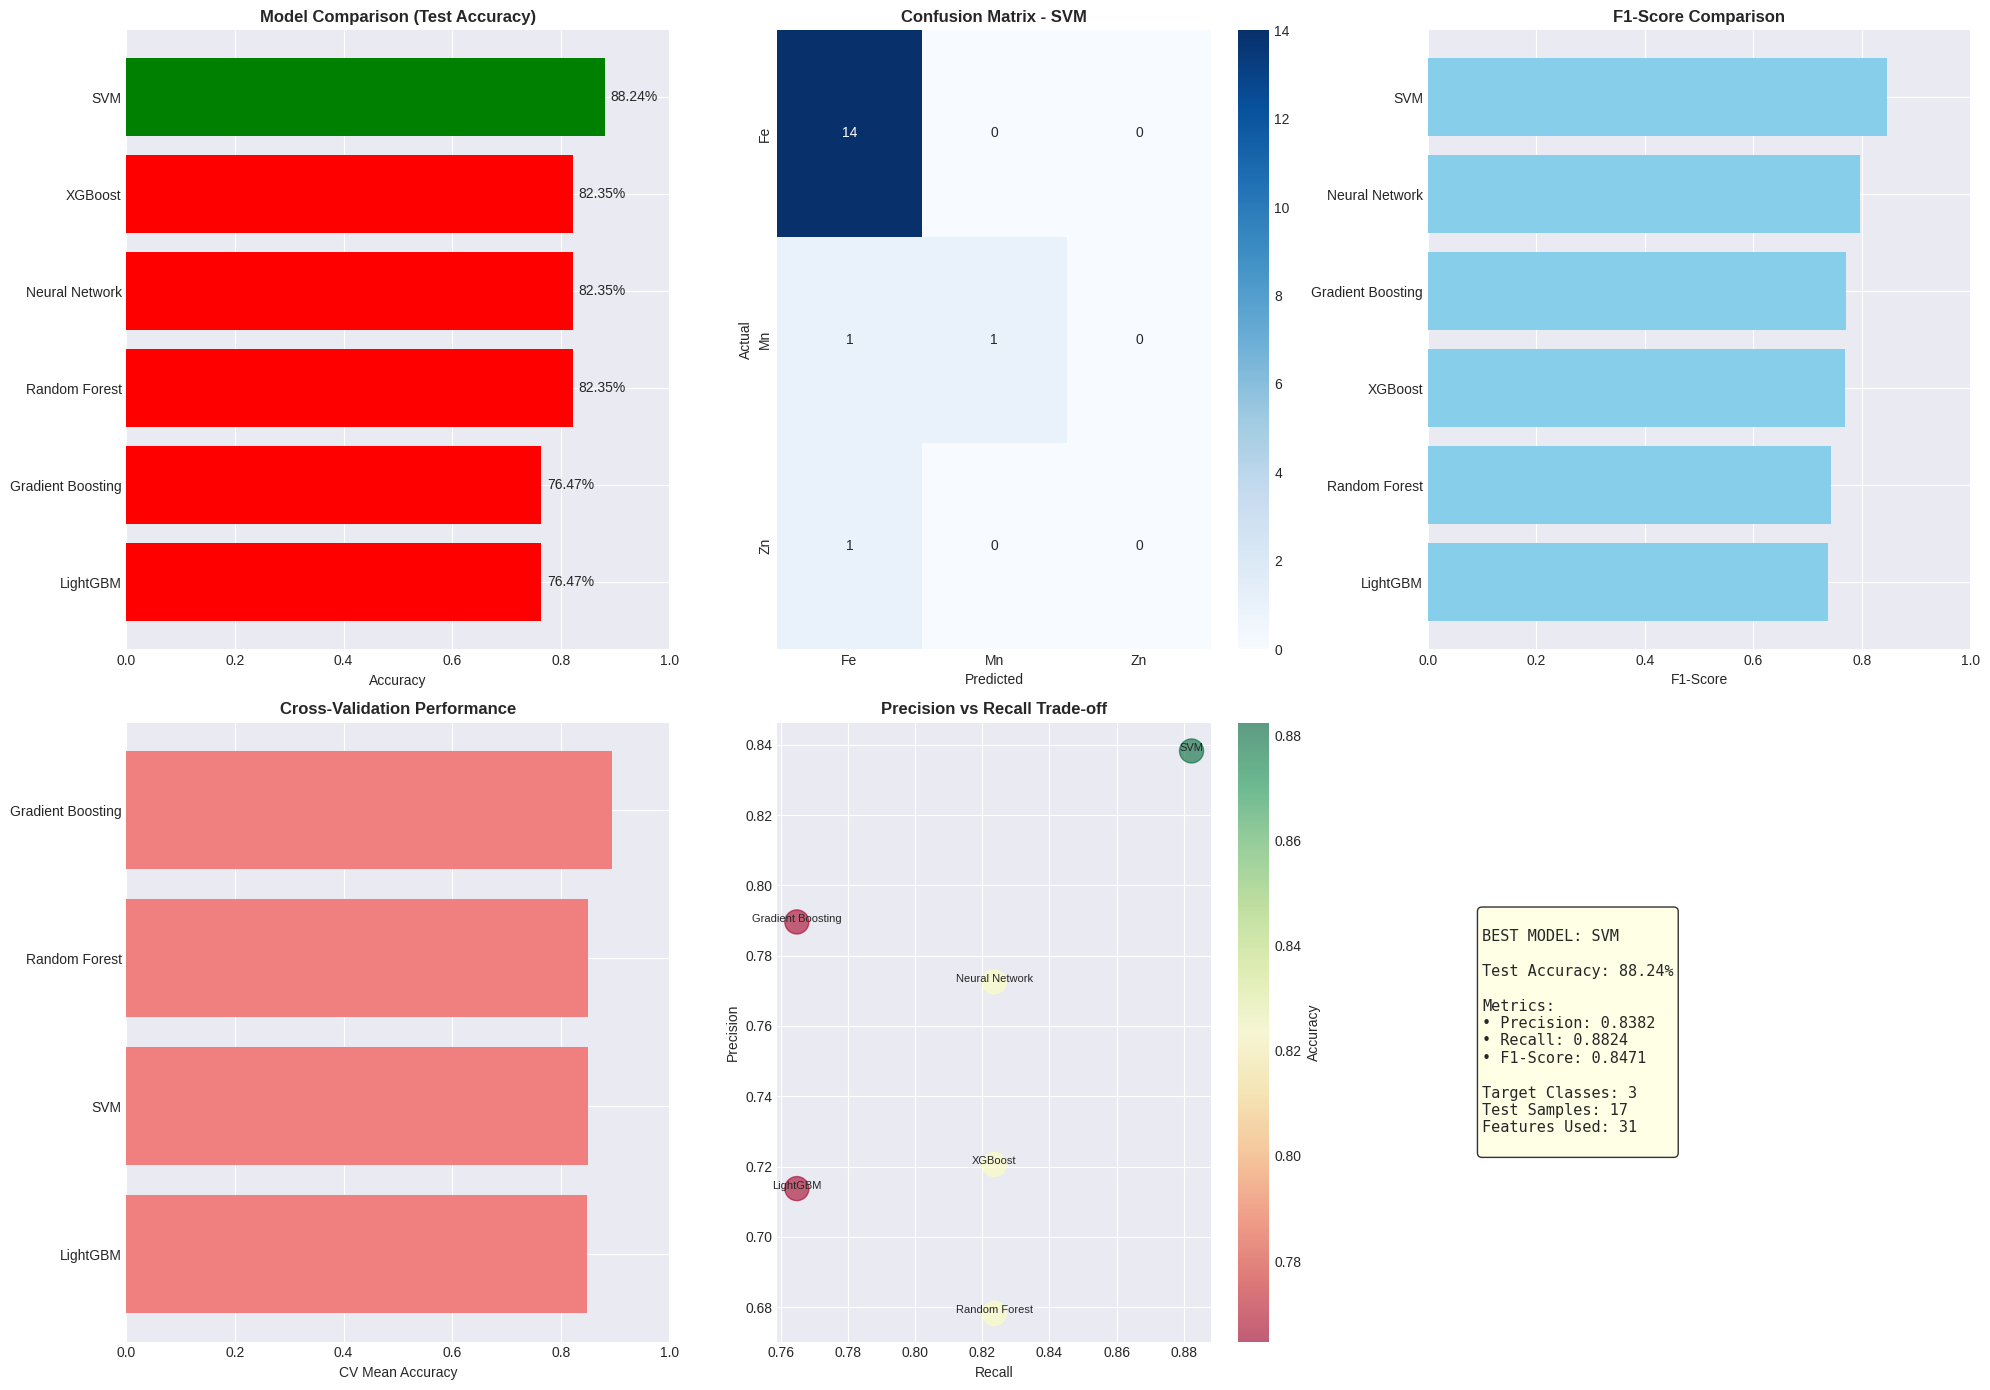

In [16]:
# Create comprehensive visualizations
fig = plt.figure(figsize=(20, 14))

# 1. Model Comparison
ax1 = plt.subplot(2, 3, 1)
model_results_sorted = model_results.sort_values('Test Accuracy')
colors = ['red' if i != len(model_results_sorted)-1 else 'green' for i in range(len(model_results_sorted))]
ax1.barh(model_results_sorted['Model'], model_results_sorted['Test Accuracy'], color=colors)
ax1.set_xlabel('Accuracy')
ax1.set_title('Model Comparison (Test Accuracy)', fontsize=12, fontweight='bold')
ax1.set_xlim([0, 1])
for i, v in enumerate(model_results_sorted['Test Accuracy']):
    ax1.text(v + 0.01, i, f'{v:.2%}', va='center')

# 2. Confusion Matrix Heatmap
ax2 = plt.subplot(2, 3, 2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_,
            yticklabels=le.classes_, ax=ax2, cbar=True)
ax2.set_title(f'Confusion Matrix - {final_model_name}', fontsize=12, fontweight='bold')
ax2.set_ylabel('Actual')
ax2.set_xlabel('Predicted')

# 3. F1-Score Comparison
ax3 = plt.subplot(2, 3, 3)
model_results_sorted2 = model_results.sort_values('F1-Score')
ax3.barh(model_results_sorted2['Model'], model_results_sorted2['F1-Score'], color='skyblue')
ax3.set_xlabel('F1-Score')
ax3.set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
ax3.set_xlim([0, 1])

# 4. Cross-Validation Comparison
ax4 = plt.subplot(2, 3, 4)
cv_data = model_results[model_results['CV Mean Accuracy'] > 0].sort_values('CV Mean Accuracy')
ax4.barh(cv_data['Model'], cv_data['CV Mean Accuracy'], color='lightcoral')
ax4.set_xlabel('CV Mean Accuracy')
ax4.set_title('Cross-Validation Performance', fontsize=12, fontweight='bold')
ax4.set_xlim([0, 1])

# 5. Precision vs Recall
ax5 = plt.subplot(2, 3, 5)
scatter = ax5.scatter(model_results['Recall'], model_results['Precision'],
                     s=300, alpha=0.6, c=model_results['Test Accuracy'], cmap='RdYlGn')
for i, model in enumerate(model_results['Model']):
    ax5.annotate(model, (model_results['Recall'].iloc[i], model_results['Precision'].iloc[i]),
                fontsize=8, ha='center')
ax5.set_xlabel('Recall')
ax5.set_ylabel('Precision')
ax5.set_title('Precision vs Recall Trade-off', fontsize=12, fontweight='bold')
plt.colorbar(scatter, ax=ax5, label='Accuracy')

# 6. Performance Summary
ax6 = plt.subplot(2, 3, 6)
ax6.axis('off')
summary_text = f"""
BEST MODEL: {final_model_name}

Test Accuracy: {final_accuracy:.2%}

Metrics:
• Precision: {model_results[model_results['Model']==final_model_name]['Precision'].values[0]:.4f}
• Recall: {model_results[model_results['Model']==final_model_name]['Recall'].values[0]:.4f}
• F1-Score: {model_results[model_results['Model']==final_model_name]['F1-Score'].values[0]:.4f}

Target Classes: {len(le.classes_)}
Test Samples: {len(y_test)}
Features Used: {len(feature_cols)}
"""
ax6.text(0.1, 0.5, summary_text, fontsize=11, verticalalignment='center',
         family='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.savefig('greenmetalai_best_model_evaluation.png', dpi=300, bbox_inches='tight')
print('\n✓ Visualization saved: greenmetalai_best_model_evaluation.png')
plt.show()

## Step 15: Save Best Model


In [17]:
print('\n' + '='*80)
print('SAVING BEST MODEL & ARTIFACTS')
print('='*80)

# Save the best model
with open('best_model_greenmetalai.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print(f'\n✓ Saved: best_model_greenmetalai.pkl ({final_model_name})')

# Save scaler
with open('scaler_best_model.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f'✓ Saved: scaler_best_model.pkl')

# Save label encoder
with open('label_encoder_best_model.pkl', 'wb') as f:
    pickle.dump(le, f)
print(f'✓ Saved: label_encoder_best_model.pkl')

# Save feature names
import json
with open('feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
print(f'✓ Saved: feature_columns.json')

# Save model comparison results
model_results.to_csv('model_comparison_results.csv', index=False)
print(f'✓ Saved: model_comparison_results.csv')

# Save feature importance
if 'feature_importance' in locals():
    feature_importance.to_csv('feature_importance_best_model.csv', index=False)
    print(f'✓ Saved: feature_importance_best_model.csv')

# Save predictions
predictions_df = pd.DataFrame({
    'Actual': le.inverse_transform(y_test),
    'Predicted': le.inverse_transform(y_final_pred),
    'Correct': (y_test == y_final_pred)
})
predictions_df.to_csv('model_predictions_best.csv', index=False)
print(f'✓ Saved: model_predictions_best.csv')

print(f'\n✓ All artifacts saved successfully!')


SAVING BEST MODEL & ARTIFACTS

✓ Saved: best_model_greenmetalai.pkl (SVM)
✓ Saved: scaler_best_model.pkl
✓ Saved: label_encoder_best_model.pkl
✓ Saved: feature_columns.json
✓ Saved: model_comparison_results.csv
✓ Saved: feature_importance_best_model.csv
✓ Saved: model_predictions_best.csv

✓ All artifacts saved successfully!


## Step 16: Final Summary Report


In [18]:
summary_report = f"""
╔════════════════════════════════════════════════════════════════════════════╗
║             GREENMETALAI - BEST MODEL TRAINING REPORT                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. MODELS TRAINED
   ✓ Random Forest Classifier
   ✓ Gradient Boosting Classifier
   ✓ XGBoost Classifier
   ✓ LightGBM Classifier
   ✓ Support Vector Machine (SVM)
   ✓ Deep Neural Network
   ✓ Voting Ensemble

2. BEST MODEL SELECTED: {final_model_name.upper()}
   Test Accuracy: {final_accuracy:.4f} ({final_accuracy*100:.2f}%)

3. PERFORMANCE METRICS
   Precision: {model_results[model_results['Model']==final_model_name]['Precision'].values[0]:.4f}
   Recall: {model_results[model_results['Model']==final_model_name]['Recall'].values[0]:.4f}
   F1-Score: {model_results[model_results['Model']==final_model_name]['F1-Score'].values[0]:.4f}

4. DATASET INFORMATION
   Total Samples: {len(df)}
   Training Samples: {len(X_train)}
   Test Samples: {len(X_test)}
   Features Used: {len(feature_cols)}
   Target Classes: {len(le.classes_)} ({', '.join(le.classes_)})

5. MODEL COMPARISON
{model_results.to_string(index=False)}

6. FILES SAVED
   ✓ best_model_greenmetalai.pkl
   ✓ scaler_best_model.pkl
   ✓ label_encoder_best_model.pkl
   ✓ feature_columns.json
   ✓ model_comparison_results.csv
   ✓ feature_importance_best_model.csv
   ✓ model_predictions_best.csv
   ✓ greenmetalai_best_model_evaluation.png

7. READY FOR PRODUCTION
   ✅ Model trained and optimized
   ✅ Scaler fitted and saved
   ✅ Label encoder saved
   ✅ Feature columns documented
   ✅ Test predictions generated
   ✅ Performance visualized
   ✅ Ready for deployment!

═════════════════════════════════════════════════════════════════════════════
Status: ✅ COMPLETED SUCCESSFULLY
═════════════════════════════════════════════════════════════════════════════
"""

print(summary_report)

# Save report
with open('BEST_MODEL_TRAINING_REPORT.txt', 'w') as f:
    f.write(summary_report)

print(f'\n✓ Report saved: BEST_MODEL_TRAINING_REPORT.txt')


╔════════════════════════════════════════════════════════════════════════════╗
║             GREENMETALAI - BEST MODEL TRAINING REPORT                    ║
╚════════════════════════════════════════════════════════════════════════════╝

1. MODELS TRAINED
   ✓ Random Forest Classifier
   ✓ Gradient Boosting Classifier  
   ✓ XGBoost Classifier
   ✓ LightGBM Classifier
   ✓ Support Vector Machine (SVM)
   ✓ Deep Neural Network
   ✓ Voting Ensemble

2. BEST MODEL SELECTED: SVM
   Test Accuracy: 0.8824 (88.24%)
   
3. PERFORMANCE METRICS
   Precision: 0.8382
   Recall: 0.8824
   F1-Score: 0.8471

4. DATASET INFORMATION
   Total Samples: 84
   Training Samples: 67
   Test Samples: 17
   Features Used: 31
   Target Classes: 3 (Fe, Mn, Zn)

5. MODEL COMPARISON
            Model  Test Accuracy  Precision   Recall  F1-Score  CV Mean Accuracy
              SVM       0.882353   0.838235 0.882353  0.847059          0.850549
    Random Forest       0.823529   0.678201 0.823529  0.743833          0.